# Runge-Kutta time-stepper

📜 _Once obtained the following_ $Q$_-coefficients :_

$$
\begin{array}
    {c|c}
    \tau & Q \\
    \hline
    & w^\top
\end{array}
$$

_we can build the associated time-stepping scheme and solve IVP problems like Ordinary Differential Equations (ODE)._

> 📣 Remember, this is exactly the same as **Butcher tables** for Runge-Kutta methods ...

Consider this simple ODE, usually named _Dahlquist equation_ :

$$
\frac{du}{dt} = \lambda u, \quad t \in [0, T], \quad u(0)=u_0.
$$

We choose here $\lambda=i$ (imaginary unit), $T=4\pi$, and $u_0=e^{\frac{i\pi}{6}}$ :

In [1]:
import numpy as np

lam = 1j
tEnd = 4*np.pi
u0 = np.exp(1j*np.pi/6)

Let's solve it using $12$ time-steps of the famous 4th order explicit Runge-Kutta method. This is how we do it with `qmat` :

In [2]:
from qmat import Q_GENERATORS

rk = Q_GENERATORS["RK4"]()
nodes, weights, Q = rk.genCoeffs()

nSteps = 12
uNum = np.zeros(nSteps+1, dtype=complex)
uNum[0] = u0

dt = tEnd/nSteps
A = np.eye(nodes.size) - lam*dt*Q  # all-at-once system

for i in range(nSteps):
    b = np.ones(nodes.size)*uNum[i]  # ... with its RHS
    uNodes = np.linalg.solve(A, b)   # ... and its solution
    uNum[i+1] = uNum[i] + lam*dt*weights.dot(uNodes)  # step update


To explain a bit, we simply computed $N=12$ time-step solutions $u_1:=u(t_1), \dots, u_n:=u(t_n) \dots, u_{N}:=u(t_N)=u(T)$,
with $t_{n+1}-t_{n} = \Delta{t} = T/N$. One time-step consists on :

1. solving the **all-at-once system** :

$$
(I - \lambda\Delta{t} Q) u_\tau = [u_n, \dots, u_n]^T,
$$

where $u_\tau$ stores the numerical approximation at $t_n + \Delta{t}\tau_m$, also called the **nodes solution** (for collocation methods) or **stage solutions** (for RK methods).

2. updating the step solution with the **step update** :

$$
u_{n+1} = u_{n} + \lambda\Delta{t} w^T u_\tau
$$

... and that's it

> 💡 The time-stepping implementation is independent from the scheme that we used (RK4) $\Rightarrow$ we can use it for any other scheme ... 

We show the time solution below, starting from the initial solution (orange square) then rotating anti-clockwise for each time-step.
The exact analytic solution in represented with the dashed black circle :

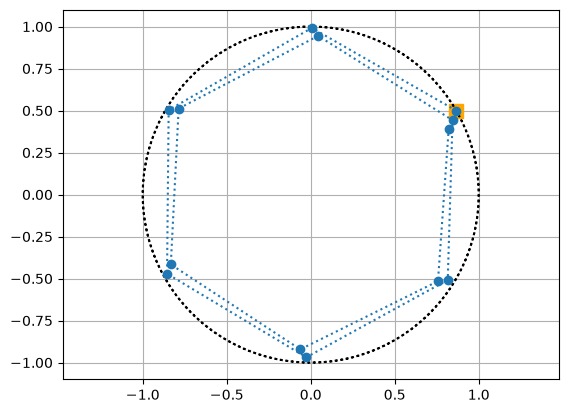

In [3]:
import matplotlib.pyplot as plt

times = np.linspace(0, tEnd, nSteps*100+1)    # finer resolution for exact solution
uExact = u0 * np.exp(lam*times)
plt.plot(uExact[0].real, uExact[0].imag, 's', ms=10, c="orange")
plt.plot(uExact.real, uExact.imag, ':', c="k")

plt.plot(uNum.real, uNum.imag, 'o:')
plt.axis("equal"), plt.grid();

As expected, we can observe **numerical errors** from the time-stepper, since all step points are not located on the unit circle as they should.
One **accuracy indicator** is the $L_\infty$ error in time (computed over all time-steps) :

In [4]:
print("L_inf error : {:1.5f}".format(np.linalg.norm(uNum-uExact[::100], ord=np.inf)))

L_inf error : 0.11925


As the amplitude of the solution is of order 1, it roughly corresponds to $\sim 12\%$ error.

Now let say we want to use a collocation method instead of RK4, using $4$ Legendre `RADAU-RIGHT` nodes (_i.e_ Radau-II). 
The only line we have to change in the previous code is :

In [5]:
# replace "rk = Q_GENERATORS["RK4"]()" by
coll = Q_GENERATORS["coll"](nNodes=4, nodeType="LEGENDRE", quadType="RADAU-RIGHT")

Then the **exact same code as before** can be used to build the time-stepper, compute the numerical solution and the error. 
For simplicity, the base $Q$-generator class in `qmat` provides a dedicated method for that :

L_inf error : 0.00001


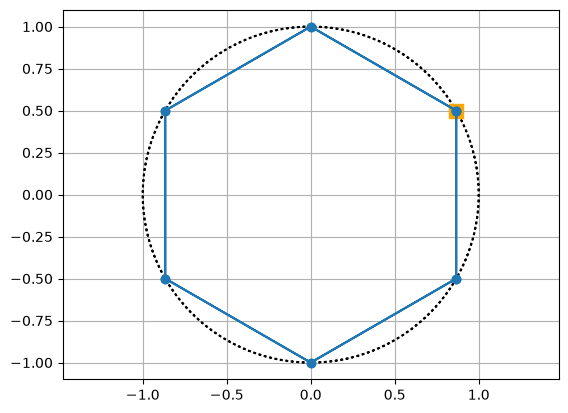

In [6]:
uNum = coll.solveDahlquist(lam, u0, tEnd, nSteps)
plt.plot(uExact.real, uExact.imag, ':', c="k")
plt.plot(uNum[0].real, uNum[0].imag, 's', ms=10, c="orange")
plt.plot(uNum.real, uNum.imag, 'o-')
plt.axis("equal")
plt.grid()
print("L_inf error : {:1.5f}".format(coll.errorDahlquist(lam, u0, tEnd, nSteps, uNum=uNum)))

Now the error is way lower, even if we used $Q$-coefficients of the same size ... but there is a major difference here between the two $Q$ matrices :

In [7]:
print(f"Q for RK4 :\n{rk.Q}")
print(f"Q for Collocation :\n{coll.Q}")

Q for RK4 :
[[0.  0.  0.  0. ]
 [0.5 0.  0.  0. ]
 [0.  0.5 0.  0. ]
 [0.  0.  1.  0. ]]
Q for Collocation :
[[ 0.11299948 -0.04030922  0.02580238 -0.00990468]
 [ 0.234384    0.20689257 -0.04785713  0.01604742]
 [ 0.21668178  0.40612326  0.18903652 -0.0241821 ]
 [ 0.22046221  0.38819347  0.32884432  0.0625    ]]


While $Q$ is **dense for the collocation method**, it is **lower triangular** for RK4, which allows to solve for the first node (or stage) first, then the second one, etc ...
Hence we need to solve $M$ equations sequentially instead of solving a system of $M$ equations **all-at-once**, reducing thus the computation cost for one time-step.
This is one main reason why RK methods have been generally favored against collocation methods.

> 🔍 In this case (Dahlquist), solving the _all-at-once system_ is easy and cheap as showed above.
> But for large scale non-linear problems, this can quickly become unfeasible, as solution at each time node may represent thousands or millions of degrees of freedom ...

💡 However, the high accuracy of collocation methods motivates to solve the _all-at-once system_ in a cheaper way, which is the main idea of **Spectral Deferred Correction (SDC)**, a.k.a **Iterated Runge-Kutta methods**.
Those use fixed-point preconditioned iterations to solve the all-at-once system, where the preconditioner is built using a **lower triangular** approximation of the $Q$ matrix, named the $Q_\Delta$ **matrix**.

In fact, the second main feature of `qmat` is to [generate those approximations ...](./3_qDelta.ipynb)